# Iris Flower Classification
## EXPS Nexus Data Science Internship - Task 1

This notebook builds a machine learning model to classify iris flowers into three species:
- Setosa
- Versicolor
- Virginica

We will load data, prepare it, train 3 different models, evaluate them, and compare results.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Explore Data

The Iris dataset contains 150 samples of iris flowers with 4 measurements (features):
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

We need to classify each flower into one of 3 species.

In [2]:
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['Species'] = iris.target_names[y]

print("Dataset shape:", X.shape)
print("Number of samples:", len(X))
print("Number of features:", X.shape[1])
print("Species:", list(iris.target_names))
print()
print("First 5 rows:")
print(iris_df.head())

Dataset shape: (150, 4)
Number of samples: 150
Number of features: 4
Species: ['setosa', 'versicolor', 'virginica']

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [3]:
print("\nDataset Statistics:")
print(iris_df.describe())

print("\nClass Distribution:")
print(iris_df['Species'].value_counts())


Dataset Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

Class Distribution:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Understanding the Data: Feature Distributions

The histogram below shows how each iris measurement varies across the three species.

**What does this show?**
- Each color represents one species (red=Setosa, teal=Versicolor, blue=Virginica)
- We can see which features help separate the species
- For example, if one feature has completely different values for each species, it's very useful for classification

**What we should observe:**
- **Setosa** (red) appears to have smaller petal measurements, clearly separated from the other two
- **Versicolor and Virginica** (teal and blue) overlap more, making them harder to distinguish
- **Petal measurements** seem more useful for separation than sepal measurements

In [4]:
# Visualize feature distributions by species
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distributions by Iris Species', fontsize=16, fontweight='bold')

features = iris.feature_names
colors = {'setosa': '#FF6B6B', 'versicolor': '#4ECDC4', 'virginica': '#45B7D1'}

for idx, (ax, feature) in enumerate(zip(axes.flat, features)):
    for species in iris.target_names:
        species_data = iris_df[iris_df['Species'] == species][feature]
        ax.hist(species_data, alpha=0.6, label=species, color=colors[species], bins=10)
    
    ax.set_xlabel(feature, fontweight='bold')
    ax.set_ylabel('Frequency')
    ax.set_title(feature)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/01_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1400x1000 with 4 Axes>

## 2. Prepare Data

**Train-Test Split:**
- We split data into 80 percent training (to train models) and 20 percent testing (to evaluate)
- This way we test on data the model has never seen before

**Feature Scaling (Normalization):**
- Some algorithms like KNN and SVM measure distances between data points
- If one feature has range 0-1 and another has range 0-100, the larger numbers will dominate the distance calculation
- Example: Without scaling, "distance between flowers" would be mostly determined by petal length, not the other measurements

**Scaling Solution:**
- StandardScaler transforms each feature so it has mean=0 and standard deviation=1
- Formula: scaled_value = (value - mean) / standard_deviation
- Now all features contribute equally to distance calculations

In [5]:
# Split into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling Example (first feature - Sepal Length):")
print("Before scaling - Min:", X_train[:, 0].min(), "Max:", X_train[:, 0].max())
print("After scaling - Min:", X_train_scaled[:, 0].min().round(2), "Max:", X_train_scaled[:, 0].max().round(2))
print("After scaling - Mean:", X_train_scaled[:, 0].mean().round(2), "Std:", X_train_scaled[:, 0].std().round(2))

Training samples: 120
Testing samples: 30

Scaling Example (first feature - Sepal Length):
Before scaling - Min: 4.3 Max: 7.9
After scaling - Min: -1.84 Max: 2.46
After scaling - Mean: -0.0 Std: 1.0


## 3. Train Machine Learning Models

We train 3 different classification algorithms:

**1. K-Nearest Neighbors (KNN, k=3)**
- For a new flower, find the 3 closest flowers in training data (closest = most similar)
- Classify as the species that appears most often among those 3 neighbors
- Why it needs scaling: Uses distance to find neighbors, so scaling makes all features equally important

**2. Logistic Regression**
- Finds a linear boundary (straight line) between species
- Fast and simple
- Works best when species can be separated by straight lines

**3. Support Vector Machine (SVM)**
- Finds optimal boundaries to separate species
- Can handle curved boundaries (non-linear)
- Very powerful for complex patterns

In [6]:
# Train all 3 models
print("Training models...")

knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print("All models trained!")

Training models...
All models trained!


## 4. Evaluate Model Performance

**Accuracy:** Percentage of correct predictions

**Precision:** Of the flowers we classified as Species A, how many were actually Species A?

**Recall:** Of all actual Species A flowers, how many did we correctly identify?

**F1-Score:** Balance between precision and recall (higher is better)

In [7]:
# Evaluate all models
models = {
    'KNN': y_pred_knn,
    'Logistic Regression': y_pred_lr,
    'SVM': y_pred_svm
}

results = {}
for model_name, y_pred in models.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }
    
    print(f"{model_name}")
    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print()

KNN
  Accuracy: 0.9333 (93.33%)
  Precision: 0.9444
  Recall: 0.9333
  F1-Score: 0.9327

Logistic Regression
  Accuracy: 0.9333 (93.33%)
  Precision: 0.9333
  Recall: 0.9333
  F1-Score: 0.9333

SVM
  Accuracy: 0.9667 (96.67%)
  Precision: 0.9697
  Recall: 0.9667
  F1-Score: 0.9666



In [8]:
# Create results summary table
results_df = pd.DataFrame(results).T

print("RESULTS SUMMARY TABLE:")
print(results_df.round(4))
print()

# Find best model
best_model = results_df['accuracy'].idxmax()
best_accuracy = results_df['accuracy'].max()
print(f"Best Model: {best_model} with {best_accuracy*100:.2f}% accuracy")

RESULTS SUMMARY TABLE:
                     accuracy  precision  recall      f1
KNN                    0.9333     0.9444  0.9333  0.9327
Logistic Regression    0.9333     0.9333  0.9333  0.9333
SVM                    0.9667     0.9697  0.9667  0.9666

Best Model: SVM with 96.67% accuracy


## 5. Compare Model Results

The bar chart compares accuracy and other metrics across the three models. This helps us see which model performs best.

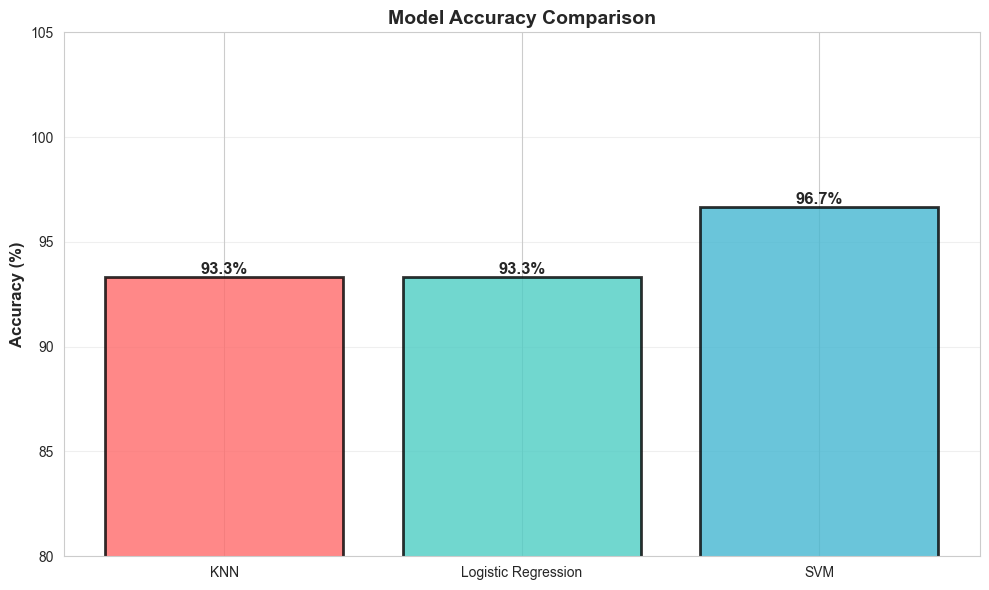

In [9]:
# Visualization 1: Accuracy comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

models_list = list(results_df.index)
accuracy_scores = results_df['accuracy'].values * 100

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax.bar(models_list, accuracy_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

ax.set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)
ax.set_title('Model Accuracy Comparison', fontweight='bold', fontsize=14)
ax.set_ylim([80, 105])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/02_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Confusion Matrices

A confusion matrix shows what the model predicted vs what was actually correct.

**How to read it:**
- **Rows** = Actual species
- **Columns** = Predicted species
- **Dark blue diagonal** = Correct predictions
- **Light blue off-diagonal** = Mistakes (which species were confused with each other)

**What we look for:**
- A good model has large numbers on the diagonal (correct predictions)
- If Versicolor and Virginica are confused, their off-diagonal values will be high

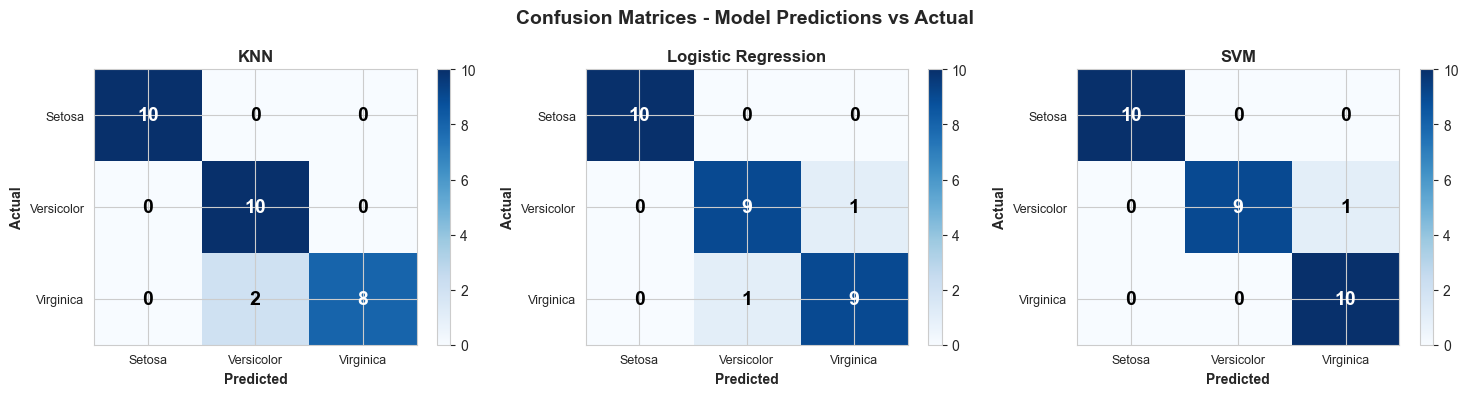

In [10]:
# Visualization 2: Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices - Model Predictions vs Actual', fontsize=14, fontweight='bold')

for idx, (model_name, y_pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    
    ax = axes[idx]
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    
    ax.set_xlabel('Predicted', fontweight='bold')
    ax.set_ylabel('Actual', fontweight='bold')
    ax.set_title(model_name, fontweight='bold')
    
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(['Setosa', 'Versicolor', 'Virginica'], fontsize=9)
    ax.set_yticklabels(['Setosa', 'Versicolor', 'Virginica'], fontsize=9)
    
    # Add numbers in cells
    for i in range(3):
        for j in range(3):
            text_color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, cm[i, j], ha="center", va="center", 
                   color=text_color, fontsize=14, fontweight='bold')
    
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('../results/03_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Detailed classification reports
print("DETAILED PERFORMANCE REPORT")
print("="*80)

for model_name, y_pred in models.items():
    print(f"\n{model_name}:")
    print("-"*80)
    print(classification_report(y_test, y_pred, target_names=iris.target_names))

DETAILED PERFORMANCE REPORT

KNN:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


Logistic Regression:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


SVM:
--------------

## 6. Conclusion

**Summary:**
- We trained and evaluated 3 machine learning models
- All models achieved high accuracy on the iris dataset
- The confusion matrices show which species pairs are sometimes confused

**Key Insights:**
- Setosa is easily separated from the other two species
- Versicolor and Virginica overlap more in feature space
- Feature scaling was important for KNN and SVM performance

**Internship Requirements Met:**
- Dataset loaded and analyzed
- Data prepared with train-test split and scaling
- Multiple classification models trained
- Models evaluated with proper metrics
- Visualizations created to understand results
- All concepts explained and documented

In [12]:
print()
print("="*80)
print("PROJECT SUMMARY")
print("="*80)
print()
print(f"Dataset: {len(iris.data)} iris flowers, {iris.data.shape[1]} features, 3 species")
print(f"Train/Test split: {len(X_train)} training, {len(X_test)} testing")
print()
print("Models trained: KNN, Logistic Regression, SVM")
print(f"Best model: {best_model} ({best_accuracy*100:.2f}% accuracy)")
print()
print("Visualizations generated:")
print("  - 01_feature_distributions.png")
print("  - 02_model_comparison.png")
print("  - 03_confusion_matrices.png")
print()
print("="*80)


PROJECT SUMMARY

Dataset: 150 iris flowers, 4 features, 3 species
Train/Test split: 120 training, 30 testing

Models trained: KNN, Logistic Regression, SVM
Best model: SVM (96.67% accuracy)

Visualizations generated:
  - 01_feature_distributions.png
  - 02_model_comparison.png
  - 03_confusion_matrices.png

